# NHL Player Style: Modeling & Cluster Analysis
**DSC 148 Course Project — Notebook 2**

This notebook covers the **Predictive Task, Model, and Results** components:
1. Position prediction (forward-vs-defense and 4-class C/L/R/D)
2. Baselines (logistic regression, naive Bayes) vs. proposed model (gradient boosting)
3. Ablation study (scoring features vs. defensive features)
4. **Cluster interpretation** — what do the discovered forward sub-styles mean?
5. Case study — the players the model misclassifies (stylistic outliers)

**Key methodological choice:** we split train/test **by player**, so a player who
appears in both seasons never lands on both sides of the split. This prevents the
model from memorizing individuals and inflating accuracy.

Run after `nhl_eda.ipynb` (which produces `player_fingerprints.csv`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

df = pd.read_csv("player_fingerprints.csv")
feat_cols = [c for c in df.columns if c.endswith("_per60")]
print("fingerprints:", df.shape, "| features:", len(feat_cols))
df.head()

fingerprints: (1443, 20) | features: 11


,playerId,skaterFullName,positionCode,seasonId,games,total_toi,goals_per60,assists_per60,points_per60,shots_per60,blockedShots_per60,hits_per60,takeaways_per60,giveaways_per60,penaltyMinutes_per60,missedShots_per60,totalShotAttempts_per60,is_forward,pos4,cluster
0,8470595,Eric Staal,C,20222023,72,61504.0,0.819459,0.877992,1.697451,6.204475,2.633975,1.580385,1.931582,1.814516,1.521852,2.107180,10.711498,1,C,0
1,8470600,Ryan Suter,D,20222023,82,100267.0,0.107712,0.789891,0.897603,3.303181,4.128976,2.908235,0.825795,1.615686,0.933508,2.118344,8.473376,0,D,3
2,8470600,Ryan Suter,D,20232024,82,93184.0,0.077266,0.579499,0.656765,3.940591,4.288290,3.322459,0.618132,1.158997,1.081731,2.356628,9.812843,0,D,3
3,8470604,Jeff Carter,C,20222023,79,64968.0,0.720355,0.886590,1.606945,7.702253,2.992242,4.432952,1.440709,1.828593,1.662357,2.493535,13.298855,1,C,0
4,8470604,Jeff Carter,C,20232024,72,54305.0,0.729215,0.265169,0.994384,5.966301,2.187644,5.502256,1.524721,1.325845,0.795507,2.916858,11.601142,1,C,0


## 1. Grouped train/test split (by player)
`GroupShuffleSplit` keeps all rows for a given `playerId` on the same side of the
split. We confirm zero player overlap.

In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, te_idx = next(gss.split(df, df["is_forward"], groups=df["playerId"]))
train, test = df.iloc[tr_idx].copy(), df.iloc[te_idx].copy()

overlap = set(train["playerId"]) & set(test["playerId"])
print(f"train={len(train)}  test={len(test)}  player overlap={len(overlap)} (must be 0)")

# Scale features on TRAIN only, apply to both (no test leakage).
scaler = StandardScaler().fit(train[feat_cols])
Xtr = scaler.transform(train[feat_cols])
Xte = scaler.transform(test[feat_cols])

train=1086  test=357  player overlap=0 (must be 0)


## 2. Task 1 — Forward vs. Defense (binary)
Baselines first, then the proposed model. We expect strong performance because
blocked shots and shot volume separate the classes cleanly (we saw this in EDA).

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

ytr, yte = train["is_forward"], test["is_forward"]
models_bin = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes":         GaussianNB(),
    "Gradient Boosting":   HistGradientBoostingClassifier(random_state=0),
}
results_bin = []
preds_bin = {}
for name, model in models_bin.items():
    model.fit(Xtr, ytr)
    p = model.predict(Xte)
    preds_bin[name] = p
    results_bin.append({"model": name,
                        "accuracy": accuracy_score(yte, p),
                        "f1": f1_score(yte, p)})
results_bin = pd.DataFrame(results_bin)
print(results_bin.round(3).to_string(index=False))

              model  accuracy    f1
Logistic Regression     0.966 0.974
        Naive Bayes     0.871 0.900
  Gradient Boosting     0.933 0.948


### Confusion matrix for the proposed model (binary)

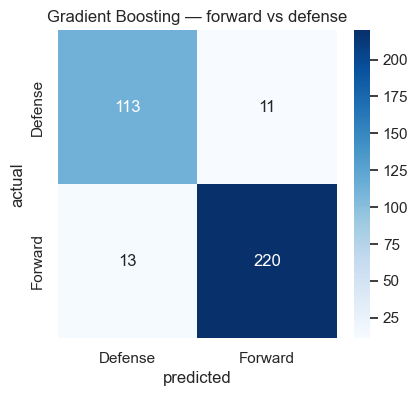

In [4]:
cm = confusion_matrix(yte, preds_bin["Gradient Boosting"])
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Defense","Forward"], yticklabels=["Defense","Forward"], ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Gradient Boosting — forward vs defense")
fig.savefig(FIGDIR/"confusion_binary.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Task 2 — 4-class C / L / R / D
The harder task. We expect the model to nail D and C but confuse L vs. R, because
left/right wing is positional convention, not playing style. The confusion matrix
is the evidence for that claim.

In [5]:
ytr4, yte4 = train["pos4"], test["pos4"]
labels4 = ["C","L","R","D"]
results_4 = []
preds_4 = {}
for name, model in [("Logistic Regression", LogisticRegression(max_iter=1000)),
                    ("Naive Bayes", GaussianNB()),
                    ("Gradient Boosting", HistGradientBoostingClassifier(random_state=0))]:
    model.fit(Xtr, ytr4)
    p = model.predict(Xte)
    preds_4[name] = p
    results_4.append({"model": name,
                      "accuracy": accuracy_score(yte4, p),
                      "macro_f1": f1_score(yte4, p, average="macro")})
results_4 = pd.DataFrame(results_4)
print(results_4.round(3).to_string(index=False))

print("\nper-class report (Gradient Boosting):")
print(classification_report(yte4, preds_4["Gradient Boosting"]))

              model  accuracy  macro_f1
Logistic Regression     0.700     0.571
        Naive Bayes     0.574     0.489
  Gradient Boosting     0.616     0.524

per-class report (Gradient Boosting):
              precision    recall  f1-score   support

           C       0.58      0.59      0.59       118
           D       0.90      0.93      0.91       124
           L       0.34      0.42      0.37        60
           R       0.29      0.18      0.22        55

    accuracy                           0.62       357
   macro avg       0.53      0.53      0.52       357
weighted avg       0.61      0.62      0.61       357



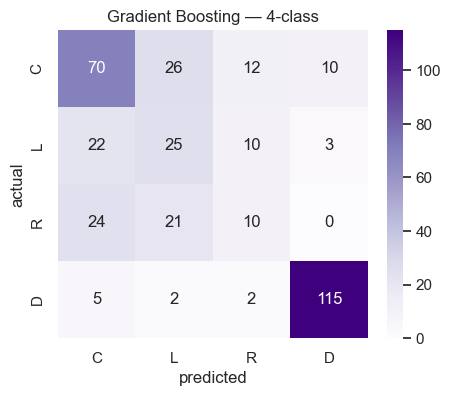

In [6]:
cm4 = confusion_matrix(yte4, preds_4["Gradient Boosting"], labels=labels4)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm4, annot=True, fmt="d", cmap="Purples",
            xticklabels=labels4, yticklabels=labels4, ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Gradient Boosting — 4-class")
fig.savefig(FIGDIR/"confusion_4class.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Ablation study
Which feature group carries the signal? We retrain the proposed model on (a) all
features, (b) scoring features only, (c) defensive features only. If defensive-only
nearly matches all-features, blocked shots / hits are doing most of the work.

In [7]:
scoring   = ["goals_per60","assists_per60","points_per60","shots_per60",
             "missedShots_per60","totalShotAttempts_per60"]
defensive = ["blockedShots_per60","hits_per60","takeaways_per60",
             "giveaways_per60","penaltyMinutes_per60"]

def eval_subset(cols):
    sc = StandardScaler().fit(train[cols])
    m = HistGradientBoostingClassifier(random_state=0).fit(sc.transform(train[cols]), ytr)
    p = m.predict(sc.transform(test[cols]))
    return accuracy_score(yte, p), f1_score(yte, p)

abl = []
for label, cols in [("all features", feat_cols),
                    ("scoring only", scoring),
                    ("defensive only", defensive)]:
    a, f = eval_subset(cols)
    abl.append({"feature set": label, "accuracy": a, "f1": f})
abl = pd.DataFrame(abl)
print(abl.round(3).to_string(index=False))

   feature set  accuracy    f1
  all features     0.933 0.948
  scoring only     0.924 0.942
defensive only     0.919 0.938


C:\Users\owenm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\owenm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\owenm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\owenm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

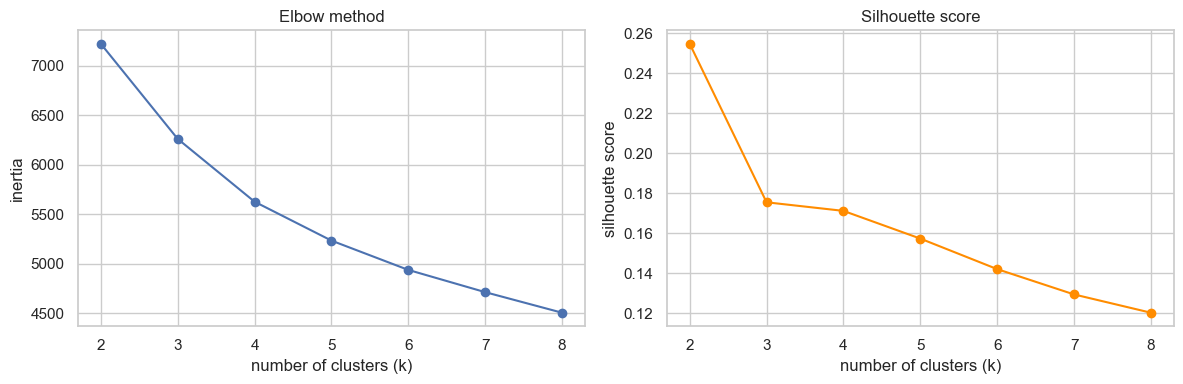

k :  inertia   silhouette
2 :    7221.1   0.255
3 :    6260.9   0.176
4 :    5626.7   0.171
5 :    5233.9   0.157
6 :    4937.9   0.142
7 :    4713.4   0.129
8 :    4505.7   0.120


In [12]:
# ---- Cluster selection: how many forward styles? ----
# We cluster FORWARDS ONLY (defensemen already separate cleanly), and choose k
# using two standard criteria: the elbow method (where inertia stops dropping
# sharply) and the silhouette score (how well-separated the clusters are).
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

fwd_sel = df[df["is_forward"] == 1].copy()
Xf = StandardScaler().fit(fwd_sel[feat_cols]).transform(fwd_sel[feat_cols])

ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xf)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xf, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(list(ks), inertias, "o-")
ax1.set_xlabel("number of clusters (k)"); ax1.set_ylabel("inertia")
ax1.set_title("Elbow method")
ax2.plot(list(ks), sils, "o-", color="darkorange")
ax2.set_xlabel("number of clusters (k)"); ax2.set_ylabel("silhouette score")
ax2.set_title("Silhouette score")
fig.tight_layout()
fig.savefig(FIGDIR/"cluster_selection.png", dpi=120, bbox_inches="tight")
plt.show()

print("k :  inertia   silhouette")
for k, i, s in zip(ks, inertias, sils):
    print(f"{k} : {i:9.1f}   {s:.3f}")

## 5. Cluster interpretation — what are the forward sub-styles?
EDA found that K-Means rediscovered defensemen on its own and split *forwards* into
sub-clusters that don't match C/L/R. Here we profile each forward cluster by its
mean per-60 stats to give each one a human label (e.g. "scorer", "playmaker",
"grinder").

Forward cluster profiles (mean per-60):
         goals_per60  assists_per60  shots_per60  hits_per60  takeaways_per60  \
cluster                                                                         
0               0.70           0.95         6.51        4.41             1.70   
1               1.21           1.57         9.26        3.39             1.85   
2               0.55           0.65         5.87       14.47             1.37   
3               0.32           0.55         4.43        5.45             1.21   

         giveaways_per60  n_players  
cluster                              
0                   1.36        477  
1                   1.82        283  
2                   1.17        120  
3                   1.15         55  


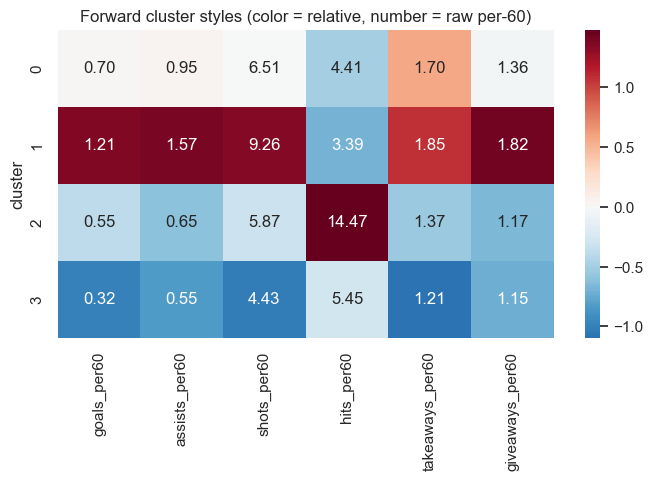

In [8]:
fwd = df[df["is_forward"] == 1].copy()
profile_stats = ["goals_per60","assists_per60","shots_per60","hits_per60",
                 "takeaways_per60","giveaways_per60"]
cluster_profile = fwd.groupby("cluster")[profile_stats].mean().round(2)
cluster_sizes = fwd["cluster"].value_counts().sort_index()
cluster_profile["n_players"] = cluster_sizes
print("Forward cluster profiles (mean per-60):")
print(cluster_profile)

# Heatmap of cluster profiles (z-scored per stat so styles pop visually)
z = (cluster_profile[profile_stats] - cluster_profile[profile_stats].mean()) / cluster_profile[profile_stats].std()
fig, ax = plt.subplots(figsize=(8,4))
sns.heatmap(z, annot=cluster_profile[profile_stats].values, fmt=".2f",
            cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Forward cluster styles (color = relative, number = raw per-60)")
ax.set_ylabel("cluster")
fig.savefig(FIGDIR/"forward_cluster_styles.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpret the table above.** For each cluster, look at which stats are high
(red) vs low (blue). Typical hockey archetypes to map onto them:
- high goals + high shots -> **scorers / snipers**
- high assists, lower shots -> **playmakers**
- high hits, low scoring -> **grinders / energy line**
- balanced -> **two-way forwards**

Name your clusters in the report based on what you actually see here.

In [9]:
# Example named forwards per cluster: list a few real players from each cluster
for cl in sorted(fwd["cluster"].unique()):
    names = fwd[fwd["cluster"]==cl]["skaterFullName"].head(6).tolist()
    print(f"cluster {cl}: {', '.join(names)}")

cluster 0: Eric Staal, Jeff Carter, Jeff Carter, Zach Parise, Zach Parise, Corey Perry
cluster 1: Patrice Bergeron, Joe Pavelski, Joe Pavelski, Alex Ovechkin, Alex Ovechkin, Evgeni Malkin
cluster 2: Ryan Reaves, Ryan Reaves, Nick Foligno, Milan Lucic, Cal Clutterbuck, Cal Clutterbuck
cluster 3: Andrew Cogliano, Andrew Cogliano, Nick Bonino, Zack Kassian, Casey Cizikas, Lukas Sedlak


## 6. Case study — misclassified players (stylistic outliers)
The players the binary model gets *wrong* are the interesting ones: defensemen who
statistically play like forwards, and forwards who play like defensemen. These are
your best qualitative examples for the report.

In [10]:
best = HistGradientBoostingClassifier(random_state=0).fit(Xtr, ytr)
test["pred_forward"] = best.predict(Xte)
test["correct"] = test["pred_forward"] == test["is_forward"]

miss = test[~test["correct"]].copy()
print(f"misclassified: {len(miss)} of {len(test)} ({100*len(miss)/len(test):.1f}%)")

cols_show = ["skaterFullName","positionCode","seasonId","is_forward","pred_forward",
             "goals_per60","shots_per60","blockedShots_per60","hits_per60"]
print("\nDefensemen the model thinks are forwards:")
print(miss[(miss.is_forward==0)][cols_show].to_string(index=False))
print("\nForwards the model thinks are defensemen:")
print(miss[(miss.is_forward==1)][cols_show].to_string(index=False))

misclassified: 24 of 357 (6.7%)

Defensemen the model thinks are forwards:
       skaterFullName positionCode  seasonId  is_forward  pred_forward  goals_per60  shots_per60  blockedShots_per60  hits_per60
      Dougie Hamilton            D  20222023           0             1     0.739289     9.241109            2.889947    2.150658
      Dougie Hamilton            D  20232024           0             1     0.715137     8.724672            3.432658    2.574493
            Brad Hunt            D  20222023           0             1     0.455350     5.236529            1.138376    1.821401
       Nikita Zadorov            D  20222023           0             1     0.548219     5.090608            2.936890    6.813584
       Nikita Zadorov            D  20232024           0             1     0.275215     4.128230            3.119107    8.118852
         Aaron Ekblad            D  20222023           0             1     0.505725     7.802607            2.889854    2.781485
        Tony DeAngelo 

## 7. Summary tables for the report
Collect the headline numbers in one place to drop into the ACM write-up.

In [11]:
print("=== TABLE 1: Forward vs Defense ===")
print(results_bin.round(3).to_string(index=False))
print("\n=== TABLE 2: 4-class C/L/R/D ===")
print(results_4.round(3).to_string(index=False))
print("\n=== TABLE 3: Ablation (forward vs defense) ===")
print(abl.round(3).to_string(index=False))

# Save tables as CSV for easy copy into the report
results_bin.to_csv("table_binary.csv", index=False)
results_4.to_csv("table_4class.csv", index=False)
abl.to_csv("table_ablation.csv", index=False)
print("\nsaved table_binary.csv, table_4class.csv, table_ablation.csv")

=== TABLE 1: Forward vs Defense ===
              model  accuracy    f1
Logistic Regression     0.966 0.974
        Naive Bayes     0.871 0.900
  Gradient Boosting     0.933 0.948

=== TABLE 2: 4-class C/L/R/D ===
              model  accuracy  macro_f1
Logistic Regression     0.700     0.571
        Naive Bayes     0.574     0.489
  Gradient Boosting     0.616     0.524

=== TABLE 3: Ablation (forward vs defense) ===
   feature set  accuracy    f1
  all features     0.933 0.948
  scoring only     0.924 0.942
defensive only     0.919 0.938

saved table_binary.csv, table_4class.csv, table_ablation.csv


In [ ]:
# ---- Export model artifacts for the static demo ----
import json
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Refit on the forward profiles (same setup as the archetypes section).
fwd_demo = df[df["is_forward"] == 1].copy()
X_fwd = fwd_demo[feat_cols].fillna(0).values

scaler_demo = StandardScaler().fit(X_fwd)
X_scaled = scaler_demo.transform(X_fwd)

km_demo = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X_scaled)
fwd_demo["cluster"] = km_demo.labels_

# Map cluster IDs to the archetype names from your paper. The cluster numbers
# come from K-Means, so figure out which cluster corresponds to which archetype
# by looking at the defining stats (Stars = highest goals, Enforcers = highest
# hits, etc.). The mapping below assumes the same random_state produces the
# same cluster ordering you reported; verify by printing the profile.
profile = fwd_demo.groupby("cluster")[feat_cols].mean().round(2)
print("Cluster profiles (verify mapping below matches paper):")
print(profile[["goals_per60", "assists_per60", "shots_per60",
               "hits_per60"]])

# Identify clusters by their defining stat (robust to random_state changes).
stars_cluster = profile["goals_per60"].idxmax()
enforcers_cluster = profile["hits_per60"].idxmax()
fourth_line_cluster = profile["shots_per60"].idxmin()
# Middle-six is the remaining cluster.
remaining = set(profile.index) - {stars_cluster, enforcers_cluster, fourth_line_cluster}
middle_six_cluster = remaining.pop()

archetype_names = {
    int(stars_cluster):       "Stars",
    int(middle_six_cluster):  "Middle-six",
    int(enforcers_cluster):   "Enforcers",
    int(fourth_line_cluster): "Fourth-line",
}
print("\nMapping cluster -> archetype:", archetype_names)

# Pick a few representative player names per cluster to display in the demo.
representative_players = {}
for cluster_id, name in archetype_names.items():
    names = (fwd_demo[fwd_demo["cluster"] == cluster_id]
             .sort_values("total_toi", ascending=False)
             ["skaterFullName"].head(5).tolist())
    representative_players[name] = names

# Bundle everything the demo needs.
artifact = {
    "feature_names": feat_cols,
    "scaler_mean": scaler_demo.mean_.tolist(),
    "scaler_scale": scaler_demo.scale_.tolist(),
    "centroids": {archetype_names[int(i)]: km_demo.cluster_centers_[i].tolist()
                  for i in range(4)},
    "representative_players": representative_players,
    "descriptions": {
        "Stars": "High-volume scorers and playmakers. Top of the lineup.",
        "Middle-six": "Balanced two-way contributors. The most common forward role.",
        "Enforcers": "Physical, hit-heavy players who provide an energy presence.",
        "Fourth-line": "Low-event checking and defensive-zone specialists.",
    }
}

demo_dir = Path("demo"); demo_dir.mkdir(exist_ok=True)
with open(demo_dir / "model.json", "w") as f:
    json.dump(artifact, f, indent=2)
print("\nWrote demo/model.json")